# Metric: deviance from log predictive probability when predicting with Bubblewrap
## Goal: Identify neurons that actually changed a trajectory

Import and load everything

In [1]:
import adaptive_latents as al
from adaptive_latents import NumpyTimedDataSource, Bubblewrap, AnimationManager, default_rwd_parameters, BWRun
from adaptive_latents.transforms.utils import prosvd_data, clip
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Specify the paths to the files
stim_file_path = '../workspace/datasets/fish/output_020424_ds1/stimmed.txt'
C_file_path = '../workspace/datasets/fish/output_020424_ds1/analysis_proc_C.txt'
photo_file_path = '../workspace/datasets/fish/output_020424_ds1/photostims.npy'

# Load the files
stim = np.loadtxt(stim_file_path) 
"""1st entry: frame number,
2nd entry: ignore,
3rd entry: angle of motion L,
4th entry: angle of motion R,
5th entry: timestamp,"""
C = np.loadtxt(C_file_path)#
"""Calcium imaging. 
1st entry is neuron ID,
2nd is time (frame)"""
photostim = np.load(photo_file_path)
"""1st entry: frame number,
2nd entry: counter of stims,
3rd entry: neuron ID,
4th entry: position X of neuron,
5th entry: position Y of neuron,"""

# extra note: Fs= 2.3 Hz

'1st entry: frame number,\n2nd entry: counter of stims,\n3rd entry: neuron ID,\n4th entry: position X of neuron,\n5th entry: position Y of neuron,'

Define a subset of C you want to work with

In [4]:
mediumC_visual = C[:200,:1114]

In [5]:
mediumC_visual.shape

(200, 1114)

Perform proSVD on it to take it to a subset k

In [6]:
smallC_visual = prosvd_data(mediumC_visual.T,7, 20, centering=True)

  0%|          | 0/1094 [00:00<?, ?it/s]

100%|██████████| 1094/1094 [00:00<00:00, 9177.54it/s]


In [7]:
smallC_visual.shape

(1094, 7)

Run BW on this subset

In [8]:
#neuron_ids = smallC_visual.T[:,1]
#frames = smallC_visual.T[0]

In [11]:
t = np.arange(smallC_visual.shape[0])
in_ds = NumpyTimedDataSource(smallC_visual, t, time_offsets=(0,1))

NameError: name 'smallC_visual' is not defined

In [10]:

bw = Bubblewrap(dim=in_ds.output_shape, **dict(default_rwd_parameters, M=100, num=20, B_thresh=-5, num_grad_q=4))

In [11]:
br = BWRun(bw=bw, in_ds=in_ds)
br.run(limit=1000, save=False)

  0%|          | 0/1000 [00:00<?, ?it/s]

1001it [00:20, 47.71it/s]                         


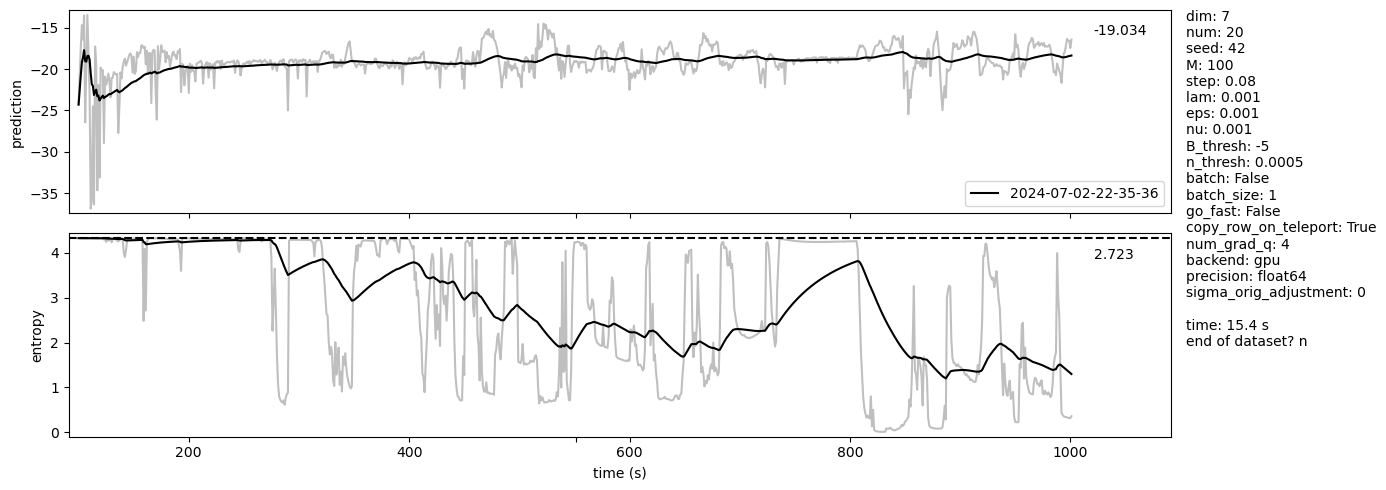

In [12]:
al.plotting_functions.compare_metrics([br], offset=1)

Figure out what's happening, because it's a really bad predictive prob

## Let's try it with both visual and photostims

In [5]:
mediumC_photo = C[:200,]

In [6]:
smallC_photo = prosvd_data(mediumC_photo.T,7, 20, centering=True)

100%|██████████| 1980/1980 [00:00<00:00, 4710.41it/s]


In [7]:
t = np.arange(smallC_photo.shape[0])
in_ds = NumpyTimedDataSource(smallC_photo, t, time_offsets=(0,1))
bw = Bubblewrap(dim=in_ds.output_shape, **dict(default_rwd_parameters, M=100, num=1000, B_thresh=-10, num_grad_q=1))

In [8]:
br = BWRun(bw=bw, in_ds=in_ds)
br.run(limit=5500, save=False)

  5%|▌         | 99/1979 [00:02<00:44, 42.40it/s] 


RuntimeError: jaxlib/gpu/solver_kernels.cc:45: operation gpusolverDnCreate(&handle) failed: cuSolver internal error

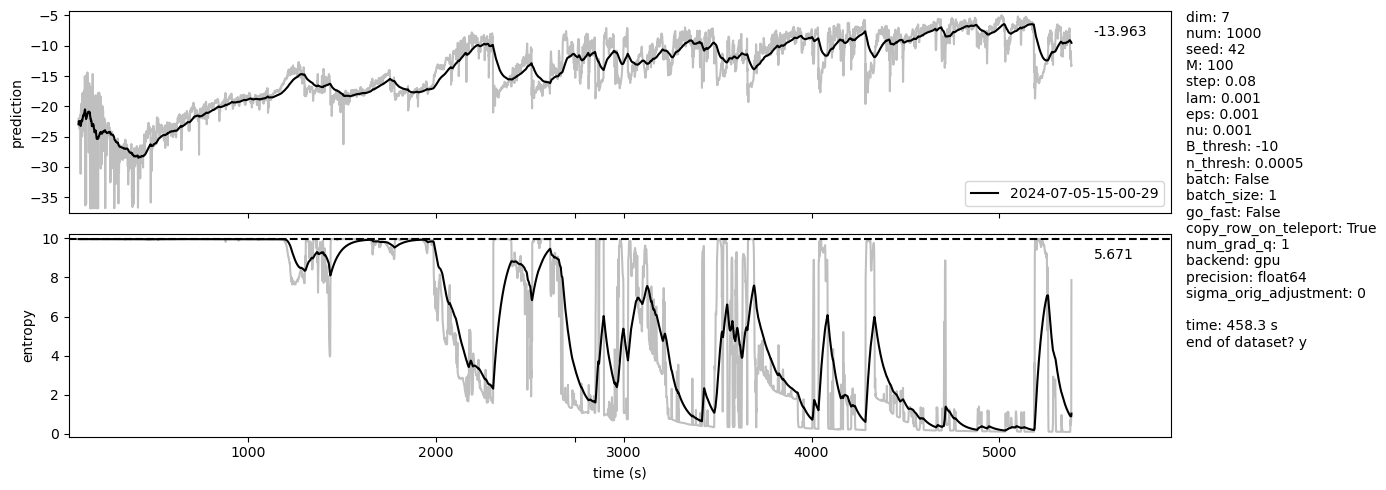

In [68]:
al.plotting_functions.compare_metrics([br], offset=1)

### Make this into a function for simplicity

In [3]:
mediumC_photo = C[:200,] #partition of interest

def BW_metric(k, m, n, mediumC_photo, default_rwd_parameters):
    # Process the data
    smallC_photo = prosvd_data(mediumC_photo.T, k, 20, centering=True)
    t = np.arange(smallC_photo.shape[0])

    # Create the data source
    in_ds = NumpyTimedDataSource(smallC_photo, t, time_offsets=(0, 1))

    # Create the Bubblewrap instance
    bw = Bubblewrap(dim=in_ds.output_shape, **dict(default_rwd_parameters, M=m, num=n, B_thresh=-10, num_grad_q=1))

    # Create the BWRun instance and run
    br = BWRun(bw=bw, in_ds=in_ds)
    br.run(limit=5000, save=False)

    al.plotting_functions.compare_metrics([br], offset=1)


  0%|          | 0/4885 [00:00<?, ?it/s]

100%|█████████▉| 4883/4884 [07:26<00:00, 10.94it/s]


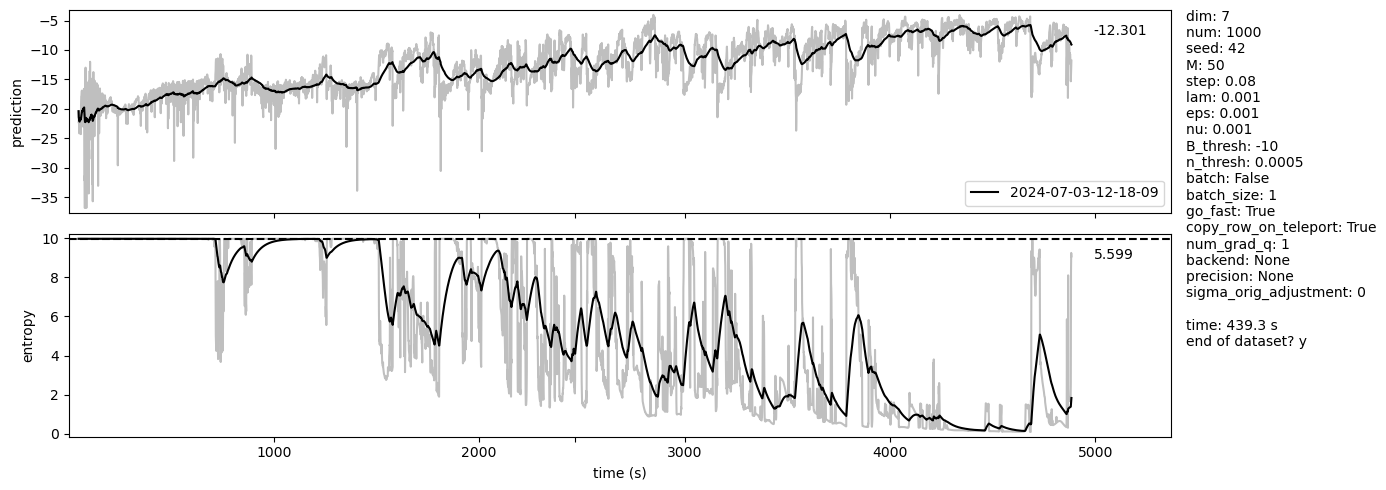

In [4]:
BW_metric(7, 50, 1000, mediumC_photo, default_rwd_parameters)

In [1]:
#Note: after n~=1250 the Kernel dies
#The function is much slower than running separately

### Add lines where photostims are

In [8]:
#To do it I need to modigy the compare_metrics function
#Ask Jonathan if I can mess around with that in the repo
def _deduce_bw_parameters(bw):
    bw: adaptive_latents.Bubblewrap
    return dict(dim=bw.d,
                num=bw.N,
                seed=bw.seed,
                M=bw.M,
                step=bw.step,
                lam=bw.lam_0,
                eps=bw.eps,
                nu=bw.nu,
                B_thresh=bw.B_thresh,
                n_thresh=bw.n_thresh,
                batch=bw.batch,
                batch_size=bw.batch_size,
                go_fast=bw.go_fast,
                copy_row_on_teleport=bw.copy_row_on_teleport,
                num_grad_q=bw.num_grad_q,
                backend=bw.backend_note,
                precision=bw.precision_note,
                sigma_orig_adjustment = bw.sigma_orig_adjust,
                )

def _one_sided_ewma(data, com=100):
    import pandas as pd
    return pd.DataFrame(data=dict(data=data)).ewm(com).mean()["data"]

def compare_metrics(brs, offset, colors=None, show_target_times=False, smoothing_scale=50, show_legend=True, show_title=True, red_lines=(), minutes=False, include_behavior=True, include_trendlines=True, red_lines_frames=None, xlim_start=None, xlim_end=None):
    colors = ["black"] + [f"C{i}" for i in range(len(brs) - 1)]
    ps = [_deduce_bw_parameters(br.bw) for br in brs]
    keys = set([leaf for tree in ps for leaf in tree.keys()])
    keep_keys = []
    for key in keys:
        values = [d.get(key) for d in ps]
        if not all([values[0] == v for v in values]):
            keep_keys.append(key)
    to_print = []
    for key in keep_keys:
        to_print.append(f"{key}: {[p.get(key) for p in ps]}")

    if hasattr(brs[0].h, 'beh_error'):
        beh_plot_raw_data = brs[0].h.beh_error[offset]
        if beh_plot_raw_data.size == 0 or np.all(np.isnan(beh_plot_raw_data)):
            include_behavior = False
    else:
        include_behavior = False

    fig, ax = plt.subplots(figsize=(14, 5), nrows=2+include_behavior, ncols=2, sharex='col', gridspec_kw={'width_ratios': [7, 1]})
    fig: plt.Figure
    to_write = [[] for _ in range(ax.shape[0])]
    last_half_times = []

    for idx, br in enumerate(brs):
        br: adaptive_latents.bw_run.BWRun

        predictions = br.h.log_pred_p[offset]
        if show_target_times:
            bw_offset_t = br.h.bw_offset_t[offset]
        else:
            bw_offset_t = br.h.bw_offset_origin_t[offset]
        smoothed_predictions = _one_sided_ewma(predictions, smoothing_scale)

        if minutes:
            bw_offset_t = bw_offset_t / 60

        c = 'black'
        if colors:
            c = colors[idx]

        last_half_times.append(br.get_last_half_time(offset))
        metrics = br.get_last_half_metrics(offset)

        ax[0, 0].plot(bw_offset_t, predictions, alpha=0.25, color=c)
        if include_trendlines:
            ax[0, 0].plot(bw_offset_t, smoothed_predictions, color=c, label=br.pickle_file.split("/")[-1].split(".")[0].split("_")[-1])
        ax[0, 0].tick_params(axis='y')
        ax[0, 0].set_ylabel('prediction')
        to_write[0].append((idx, f"{metrics['log_pred_p']:.3f}", dict(color=c)))

        entropy = br.h.entropy[offset]
        smoothed_entropy = _one_sided_ewma(entropy, smoothing_scale)

        c = 'black'
        if colors:
            c = colors[idx]
        ax[1, 0].plot(bw_offset_t, entropy, color=c, alpha=0.25)

        if include_trendlines:
            ax[1, 0].plot(bw_offset_t, smoothed_entropy, color=c)
        max_entropy = np.log2(br.bw.N)
        ax[1, 0].axhline(max_entropy, color='k', linestyle='--')

        ax[1, 0].tick_params(axis='y')
        ax[1, 0].set_ylabel('entropy')
        to_write[1].append((idx, f"{metrics['entropy']:.3f}", dict(color=c)))

        if include_behavior:
            beh_error = np.squeeze(br.h.beh_error[offset] ** 2)
            c = 'black'
            if colors:
                c = colors[idx]
            if show_target_times:
                beh_t = br.h.reg_offset_t[offset]
            else:
                beh_t = br.h.reg_offset_origin_t[offset]

            ax[-1, 0].plot(beh_t, beh_error, color=c)
            ax[-1, 0].set_ylabel('behavior sq.e.')
            ax[-1, 0].tick_params(axis='y')

            to_write[2].append((idx, " ".join([f"{x :.2f}" for x in metrics['beh_sq_error']]), dict(color=c)))

    for axis in ax[:, 0]:
        data_lim = np.array(axis.dataLim).T.flatten()
        bounds = data_lim
        bounds[:2] = (bounds[:2] - bounds[:2].mean()) * np.array([1.02, 1.2]) + bounds[:2].mean()
        bounds[2:] = (bounds[2:] - bounds[2:].mean()) * np.array([1.05, 1.05]) + bounds[2:].mean()

        axis.axis(bounds)

    for i, l in enumerate(to_write):
        for idx, text, kw in l:
            x, y = .93, .93 - .1 * idx
            x, y = ax[i, 0].transLimits.inverted().transform([x, y])
            ax[i, 0].text(x, y, text, clip_on=True, verticalalignment='top', **kw)

    if xlim_start is not None and xlim_end is not None:
        for axis in ax[:, 0]:
            axis.set_xlim(xlim_start, xlim_end)

    for axis in ax[:, 0]:
        axis.format_coord = lambda x, y: 'x={:g}, y={:g}'.format(x, y)

    # Add red lines for frame numbers if provided
    if red_lines_frames is not None:
        print(f"Adding red lines at frame numbers: {red_lines_frames}")  # Debug print
        for frame in red_lines_frames:
            for axis in ax[:, 0]:
                if (xlim_start is None or frame >= xlim_start) and (xlim_end is None or frame <= xlim_end):
                    axis.axvline(frame, color='red', linestyle='--', alpha=0.7)

    for axis in ax[:, 0]:
        axis: plt.Axes
        for line in red_lines:
            axis.axvline(line, color='red', alpha=.5)

    if show_title:
        ax[0, 0].set_title(" ".join(to_print))
    else:
        print(to_print)
    if show_legend:
        ax[0, 0].legend(loc="lower right")

    gs = ax[0, 1].get_gridspec()
    for a in ax[:, 1]:
        a.remove()
    axbig = fig.add_subplot(gs[:, 1])
    axbig.axis("off")
    to_write = "\n".join([f"{k}: {v}" for k, v in ps[0].items()])
    to_write += f"\n\ntime: {br.runtime_since_init:.1f} s\nend of dataset? {'y' if br.hit_end_of_dataset else 'n'}"
    for note in br.notes:
        to_write += f"\n{note}"
    axbig.text(0, 1, to_write, transform=axbig.transAxes, verticalalignment="top")



Adding red lines at frame numbers: [1114. 1148. 1182. 1216. 1249. 1284. 1318. 1352. 1386. 1418. 1454. 1488.
 1522. 1555. 1590. 1624. 1658. 1693. 1727. 1759. 1794. 1829. 1864. 1899.
 1935. 1969. 2002. 2036. 2069. 2106. 2142. 2176. 2212. 2246. 2280. 2310.
 2345. 2381. 2413. 2448. 2484. 2518. 2552. 2585. 2621. 2655. 2689. 2721.
 2757. 2791. 2824. 2854. 2893. 2927. 2961. 2995. 3027. 3062. 3095. 3129.
 3167. 3201. 3233. 3269. 3302. 3338. 3372. 3406. 3440. 3472. 3508. 3541.
 3576. 3610. 3644. 3674. 3706. 3739. 3775. 3812. 3848. 3882. 3916. 3950.
 3984. 4018. 4052. 4085. 4111. 4150. 4185. 4221. 4258. 4291. 4323. 4355.
 4394. 4429. 4465. 4499. 4533. 4567. 4601. 4635. 4669. 4703. 4733. 4771.
 4804. 4839. 4873. 4910. 4944. 4976. 5008. 5047. 5076. 5110. 5147. 5185.
 5217. 5245. 5280. 5324. 5355. 5391.]


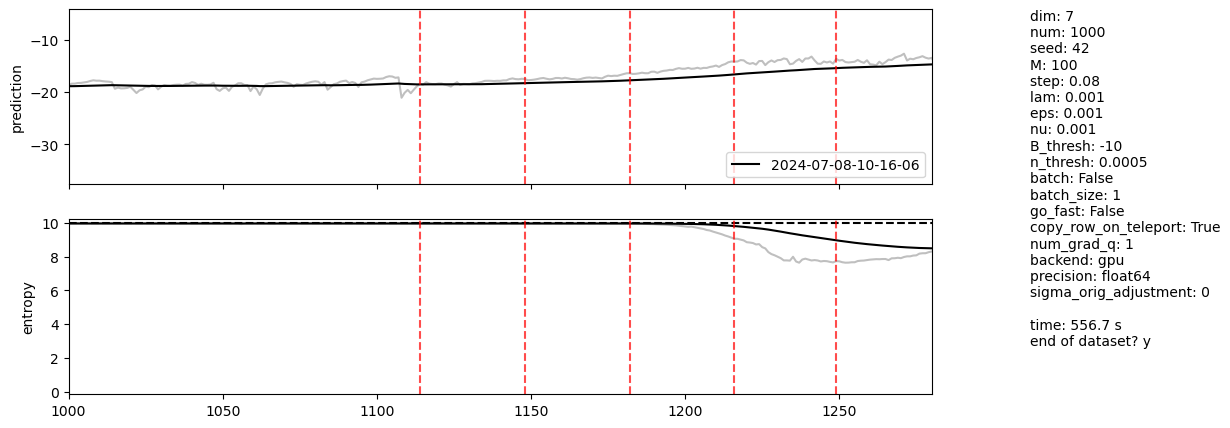

In [10]:
# Example usage
photostim = np.load("output_020424_ds1/photostims.npy")
frame_numbers = photostim[:, 0]

compare_metrics([br], offset=1, red_lines_frames=frame_numbers, xlim_start=1000, xlim_end=1280)

## Now rank changes in log predictive probability

In [15]:
#This is where predictions are stored in BW
br.h.log_pred_p[1].shape

(5284,)

In [16]:
def extract_predictions(brs, offset):
    all_predictions = []

    for br in brs:
        predictions = br.h.log_pred_p[offset]
        all_predictions.append(predictions)

    return all_predictions

In [37]:
#Put the Log PP predictions in a list
predictions_list = extract_predictions([br], offset=1)
len(predictions_list[0])

5284

In [44]:
import pandas as pd

# Create DataFrame for stim
stim_columns = ['frame_number', 'ignore', 'angle_of_motion_L', 'angle_of_motion_R', 'timestamp']
stim_df = pd.DataFrame(stim, columns=stim_columns)

# Create DataFrame for C, where each column after the first represents a neuron
neuron_ids = [f'neuron_{i}' for i in range(C.shape[0])]
time_points = [f'frame_{i}' for i in range(C.shape[1])]
C_df = pd.DataFrame(C.T, columns=neuron_ids, index=time_points)

# Create DataFrame for photostim
photostim_columns = ['frame_number', 'stim_counter', 'neuron_ID', 'position_X', 'position_Y']
photostim_df = pd.DataFrame(photostim, columns=photostim_columns)

# Set the option to display more rows
pd.set_option('display.max_rows', 110)  # Adjust the number to the desired number of rows

# Display the DataFrames
# Display different ranges of rows
#print("Photostim DataFrame - Rows 0 to 9:\n", photostim_df.iloc[0:10])
#print("\nPhotostim DataFrame - Rows 50 to 59:\n", photostim_df.iloc[50:60])
print("\nPhotostim DataFrame - Rows 0 to 99:\n", photostim_df.iloc[:10])



Photostim DataFrame - Rows 0 to 99:
    frame_number  stim_counter  neuron_ID  position_X  position_Y
0        1114.0           1.0      109.0  394.353241  247.732895
1        1148.0           2.0      109.0  394.353241  247.732895
2        1182.0           3.0      109.0  394.353241  247.732895
3        1216.0           4.0      109.0  394.353241  247.732895
4        1249.0           5.0      109.0  394.353241  247.732895
5        1284.0           6.0       98.0  259.920380  207.710526
6        1318.0           7.0       98.0  259.920380  207.710526
7        1352.0           8.0       98.0  259.920380  207.710526
8        1386.0           9.0       98.0  259.920380  207.710526
9        1418.0          10.0       98.0  259.920380  207.710526


In [38]:
len(photostim_df)

126

In [47]:
# Ensure the frame_number and neuron_ID are of integer type
photostim_df['frame_number'] = photostim_df['frame_number'].astype(int)
photostim_df['neuron_ID'] = photostim_df['neuron_ID'].astype(int)


In [66]:
print("\nPhotostim DataFrame - Rows 0 to 99:\n", photostim_df.iloc[:10])


Photostim DataFrame - Rows 0 to 99:
    frame_number  stim_counter  neuron_ID  position_X  position_Y
0          1114           1.0        109  394.353241  247.732895
1          1148           2.0        109  394.353241  247.732895
2          1182           3.0        109  394.353241  247.732895
3          1216           4.0        109  394.353241  247.732895
4          1249           5.0        109  394.353241  247.732895
5          1284           6.0         98  259.920380  207.710526
6          1318           7.0         98  259.920380  207.710526
7          1352           8.0         98  259.920380  207.710526
8          1386           9.0         98  259.920380  207.710526
9          1418          10.0         98  259.920380  207.710526


In [5]:
# Sort the photostim_df by 'frame_number'
photostim_df = photostim_df.sort_values(by='frame_number').reset_index(drop=True)

# Create a dictionary to store the results
neuron_predictions = {}

# Initialize variables to keep track of the current neuron and the starting index
current_neuron = None
start_idx = 0

# Iterate over the sorted DataFrame
for i in range(len(photostim_df)):
    row = photostim_df.iloc[i]
    frame_number = row['frame_number']
    neuron_id = row['neuron_ID']
    
    # Ensure frame_number is an integer
    frame_number = int(frame_number)
    
    # Print debug information
    #print(f"Processing row {i}: frame_number={frame_number}, neuron_id={neuron_id}, start_idx={start_idx}")
    #print(f"Types - frame_number: {type(frame_number)}, start_idx: {type(start_idx)}")
    
    # Check if we have moved to a different neuron
    if neuron_id != current_neuron:
        # If it's not the first neuron, save the previous neuron's predictions
        if current_neuron is not None:
            neuron_predictions[current_neuron].append(predictions_list[0][start_idx:frame_number])
        
        # Update the current neuron and initialize its list if necessary
        current_neuron = neuron_id
        if current_neuron not in neuron_predictions:
            neuron_predictions[current_neuron] = []
        
        # Update the start index to the current frame number
        start_idx = frame_number

# Add the last neuron's predictions
neuron_predictions[current_neuron].append(predictions_list[0][start_idx:])


neuron_id = 109  # Using integer neuron ID
if neuron_id in neuron_predictions:
    print(f"Prediction values for neuron_{neuron_id}: {neuron_predictions[neuron_id]}")
else:
    print(f"neuron_{neuron_id} not found in the data.")

NameError: name 'photostim_df' is not defined

In [60]:
# Compare last result to this to ensure we are doing things correctly
predictions_list[0][1114:1283]

array([-14.31955185, -14.17173746, -14.20585354, -14.16490753,
       -13.89763385, -13.95499757, -14.39946522, -14.61865581,
       -14.45916944, -14.76482623, -14.08973415, -14.06669178,
       -14.86038603, -14.30337146, -13.9730082 , -14.26952659,
       -13.91784328, -13.8760816 , -13.58986562, -13.71264136,
       -14.69416842, -14.57719767, -14.05313836, -13.71572552,
       -14.25102671, -13.59874333, -13.59469926, -13.23269063,
       -13.96208424, -14.5847309 , -14.62215642, -14.16474001,
       -14.35885995, -14.17194265, -14.58195821, -13.68203105,
       -13.98938644, -13.87303885, -14.27483671, -14.36019463,
       -14.28941255, -14.21734108, -13.87761331, -14.21463495,
       -14.42700222, -13.93598845, -14.70315568, -14.76440861,
       -14.90127385, -14.21166677, -14.68027222, -14.29479882,
       -13.80654144, -13.88795975, -13.4707284 , -13.24328526,
       -13.05036386, -12.67970518, -13.97973213, -13.6355718 ,
       -13.7419097 , -13.50455463, -13.36452375, -13.15

In [62]:
# Calculate and display the average of the prediction values for each neuron
neuron_averages = {neuron_id: sum(values[0]) / len(values[0]) for neuron_id, values in neuron_predictions.items() if len(values[0]) > 0}

# Print the average prediction values for each neuron
for neuron_id, avg in neuron_averages.items():
    print(f"Average prediction value for neuron_{neuron_id}: {avg:.2f}")

Average prediction value for neuron_109.0: -15.68
Average prediction value for neuron_98.0: -17.82
Average prediction value for neuron_87.0: -16.89
Average prediction value for neuron_249.0: -17.08
Average prediction value for neuron_204.0: -15.40
Average prediction value for neuron_18.0: -10.59
Average prediction value for neuron_246.0: -14.16
Average prediction value for neuron_353.0: -14.68
Average prediction value for neuron_247.0: -12.67
Average prediction value for neuron_387.0: -12.18
Average prediction value for neuron_166.0: -12.41
Average prediction value for neuron_132.0: -11.56
Average prediction value for neuron_14.0: -9.61
Average prediction value for neuron_31.0: -11.76
Average prediction value for neuron_156.0: -12.15
Average prediction value for neuron_294.0: -8.79
Average prediction value for neuron_123.0: -8.16
Average prediction value for neuron_452.0: -10.61
Average prediction value for neuron_411.0: -8.22
Average prediction value for neuron_28.0: -7.46
Average pre

In [71]:

# Calculate the drop in prediction value for each neuron compared to the neuron before it in the DataFrame
neuron_drops = {}
previous_neuron_id = None
previous_avg = None

# Iterate through the original order in the DataFrame
for neuron_id in photostim_df['neuron_ID'].unique():
    current_avg = neuron_averages[neuron_id]
    if previous_avg is not None:
        neuron_drops[neuron_id] = previous_avg - current_avg
    previous_neuron_id = neuron_id
    previous_avg = current_avg

# Rank the neurons based on the drop in prediction value
ranked_neurons = sorted(neuron_drops.items(), key=lambda x: x[1], reverse=True)
ranked_neurons

[(103, 3.9192609351259096),
 (246, 3.570870998329326),
 (452, 2.4544361303277107),
 (31, 2.151322935776383),
 (98, 2.1390340198170055),
 (353, 0.527148646953222),
 (156, 0.394209977986792),
 (166, 0.23050952422196502),
 (249, 0.1905948678605398),
 (387, -0.48993797812460294),
 (330, -0.5466539549784661),
 (123, -0.6374074370267167),
 (28, -0.7585157288416173),
 (132, -0.8463753639336833),
 (87, -0.9278311031770166),
 (82, -1.648916709380451),
 (204, -1.6833418515944754),
 (14, -1.9531302338650267),
 (247, -2.0158414907261655),
 (411, -2.3890914189241528),
 (294, -3.35999117260336),
 (18, -4.811724237647388)]

In [2]:
#let's visualize the neuron with the biggest drop
photostim_df[photostim_df['neuron_ID'] == 246]

NameError: name 'photostim_df' is not defined

Adding red lines at frame numbers: [1114. 1148. 1182. 1216. 1249. 1284. 1318. 1352. 1386. 1418. 1454. 1488.
 1522. 1555. 1590. 1624. 1658. 1693. 1727. 1759. 1794. 1829. 1864. 1899.
 1935. 1969. 2002. 2036. 2069. 2106. 2142. 2176. 2212. 2246. 2280. 2310.
 2345. 2381. 2413. 2448. 2484. 2518. 2552. 2585. 2621. 2655. 2689. 2721.
 2757. 2791. 2824. 2854. 2893. 2927. 2961. 2995. 3027. 3062. 3095. 3129.
 3167. 3201. 3233. 3269. 3302. 3338. 3372. 3406. 3440. 3472. 3508. 3541.
 3576. 3610. 3644. 3674. 3706. 3739. 3775. 3812. 3848. 3882. 3916. 3950.
 3984. 4018. 4052. 4085. 4111. 4150. 4185. 4221. 4258. 4291. 4323. 4355.
 4394. 4429. 4465. 4499. 4533. 4567. 4601. 4635. 4669. 4703. 4733. 4771.
 4804. 4839. 4873. 4910. 4944. 4976. 5008. 5047. 5076. 5110. 5147. 5185.
 5217. 5245. 5280. 5324. 5355. 5391.]


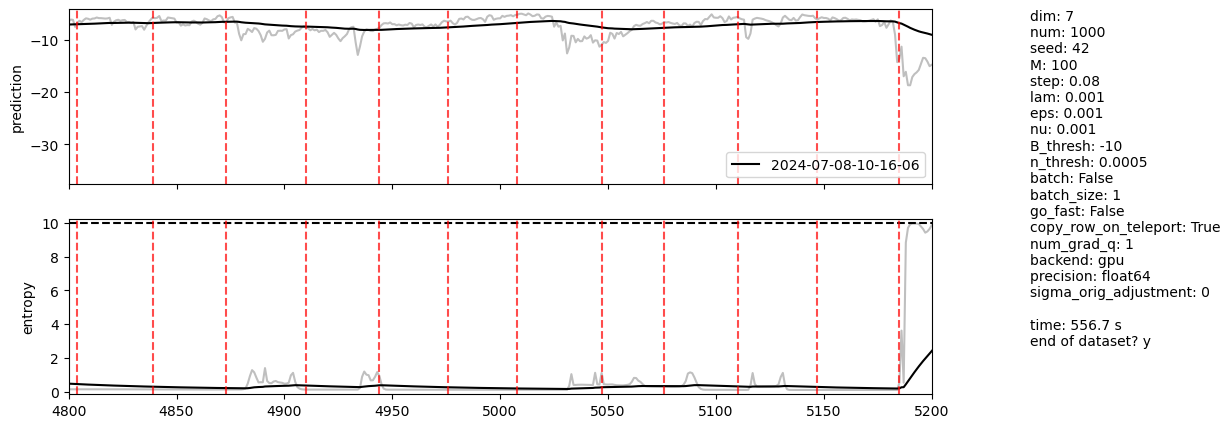

: 

In [75]:
compare_metrics([br], offset=1, red_lines_frames=frame_numbers, xlim_start=4800, xlim_end=5200)

Handling the two repeated neurons

In [10]:
import pandas as pd

# Create DataFrame for stim
stim_columns = ['frame_number', 'ignore', 'angle_of_motion_L', 'angle_of_motion_R', 'timestamp']
stim_df = pd.DataFrame(stim, columns=stim_columns)

# Create DataFrame for C, where each column after the first represents a neuron
neuron_ids = [f'neuron_{i}' for i in range(C.shape[0])]
time_points = [f'frame_{i}' for i in range(C.shape[1])]
C_df = pd.DataFrame(C.T, columns=neuron_ids, index=time_points)

# Create DataFrame for photostim
photostim_columns = ['frame_number', 'stim_counter', 'neuron_ID', 'position_X', 'position_Y']
photostim_df = pd.DataFrame(photostim, columns=photostim_columns)

# Set the option to display more rows
pd.set_option('display.max_rows', 110)  # Adjust the number to the desired number of rows

# Display the DataFrames
# Display different ranges of rows
#print("Photostim DataFrame - Rows 0 to 9:\n", photostim_df.iloc[0:10])
#print("\nPhotostim DataFrame - Rows 50 to 59:\n", photostim_df.iloc[50:60])
print("\nPhotostim DataFrame - Rows 0 to 99:\n", photostim_df.iloc[:10])


Photostim DataFrame - Rows 0 to 99:
    frame_number  stim_counter  neuron_ID  position_X  position_Y
0        1114.0           1.0      109.0  394.353241  247.732895
1        1148.0           2.0      109.0  394.353241  247.732895
2        1182.0           3.0      109.0  394.353241  247.732895
3        1216.0           4.0      109.0  394.353241  247.732895
4        1249.0           5.0      109.0  394.353241  247.732895
5        1284.0           6.0       98.0  259.920380  207.710526
6        1318.0           7.0       98.0  259.920380  207.710526
7        1352.0           8.0       98.0  259.920380  207.710526
8        1386.0           9.0       98.0  259.920380  207.710526
9        1418.0          10.0       98.0  259.920380  207.710526


In [14]:

# Group by 'neuron_ID' and count occurrences of 'position_X'
neuron_position_counts = photostim_df.groupby('neuron_ID')['position_X'].count()

# Filter neurons with more than 6 occurrences
neurons_with_many_positions = neuron_position_counts[neuron_position_counts > 6].index

# Display the result
filtered_neurons_df = photostim_df[photostim_df['neuron_ID'].isin(neurons_with_many_positions)]

print("Neurons with more than 6 occurrences of the same position_X:\n", filtered_neurons_df)


Neurons with more than 6 occurrences of the same position_X:
      frame_number  stim_counter  neuron_ID  position_X  position_Y
5          1284.0           6.0       98.0  259.920380  207.710526
6          1318.0           7.0       98.0  259.920380  207.710526
7          1352.0           8.0       98.0  259.920380  207.710526
8          1386.0           9.0       98.0  259.920380  207.710526
9          1418.0          10.0       98.0  259.920380  207.710526
60         3167.0          61.0       14.0  310.375977  394.756104
61         3201.0          62.0       14.0  310.375977  394.756104
62         3233.0          63.0       14.0  310.375977  394.756104
63         3269.0          64.0       14.0  310.375977  394.756104
64         3302.0          65.0       14.0  310.375977  394.756104
80         3848.0          81.0       14.0  310.375977  394.756104
81         3882.0          82.0       14.0  310.375977  394.756104
82         3916.0          83.0       14.0  310.375977  394.756104


In [2]:
# Group by 'neuron_ID' and count occurrences of 'position_X'
neuron_position_counts = photostim_df.groupby('neuron_ID')['position_X'].count()

# Filter neurons with more than 6 occurrences
neurons_with_many_positions = neuron_position_counts[neuron_position_counts > 6].index

# Filter the DataFrame to include only these neurons
filtered_neurons_df = photostim_df[photostim_df['neuron_ID'].isin(neurons_with_many_positions)]

# Function to modify the neuron ID for the second group of 5 occurrences
def modify_neuron_ids(df):
    modified_ids = df.copy()
    neuron_groups = modified_ids.groupby('neuron_ID')
    
    for neuron_id, group in neuron_groups:
        # Split the group into sets of 5
        for i in range(1, len(group) // 5 + 1):
            start_idx = i * 5
            if start_idx < len(group):
                modified_ids.loc[group.index[start_idx:start_idx + 5], 'neuron_ID'] = str(int(neuron_id) + 1)
    
    return modified_ids

# Apply the function to modify the neuron IDs in the original DataFrame
modified_photostim_df = modify_neuron_ids(photostim_df)


NameError: name 'photostim_df' is not defined

In [3]:
modified_photostim_df.iloc[105:110]

NameError: name 'modified_photostim_df' is not defined

In [4]:
#Now repeat the ranking process
# Sort the photostim_df by 'frame_number'
photostim_df = modified_photostim_df.sort_values(by='frame_number').reset_index(drop=True)

# Create a dictionary to store the results
neuron_predictions = {}

# Initialize variables to keep track of the current neuron and the starting index
current_neuron = None
start_idx = 0

# Iterate over the sorted DataFrame
for i in range(len(photostim_df)):
    row = photostim_df.iloc[i]
    frame_number = row['frame_number']
    neuron_id = row['neuron_ID']
    
    # Ensure frame_number is an integer
    frame_number = int(frame_number)
    
    # Print debug information
    #print(f"Processing row {i}: frame_number={frame_number}, neuron_id={neuron_id}, start_idx={start_idx}")
    #print(f"Types - frame_number: {type(frame_number)}, start_idx: {type(start_idx)}")
    
    # Check if we have moved to a different neuron
    if neuron_id != current_neuron:
        # If it's not the first neuron, save the previous neuron's predictions
        if current_neuron is not None:
            neuron_predictions[current_neuron].append(predictions_list[0][start_idx:frame_number])
        
        # Update the current neuron and initialize its list if necessary
        current_neuron = neuron_id
        if current_neuron not in neuron_predictions:
            neuron_predictions[current_neuron] = []
        
        # Update the start index to the current frame number
        start_idx = frame_number

# Add the last neuron's predictions
neuron_predictions[current_neuron].append(predictions_list[0][start_idx:])


neuron_id = 109  # Using integer neuron ID
if neuron_id in neuron_predictions:
    print(f"Prediction values for neuron_{neuron_id}: {neuron_predictions[neuron_id]}")
else:
    print(f"neuron_{neuron_id} not found in the data.")

NameError: name 'modified_photostim_df' is not defined